# Algorithm Simulation

Use `Functions_Algorithms.py` to build a named algorithm, decompose it into a star-topology pulse sequence, attach lab transition metadata from a supplied mapping, and simulate the sequence with the current noise model.


In [26]:
import io
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from scipy.linalg import expm
from scipy.special import voigt_profile
from matplotlib import rcParams

module_dir = Path(r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from Functions_Algorithms import compile_algorithm_pulses

np.set_printoptions(precision=4, suppress=True)

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = False


In [27]:
def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state


In [28]:
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi


def wrap_frame(z_frame):
    z = np.asarray(z_frame, dtype=float)
    return np.array([wrap_pi(value) for value in z], dtype=float)


def relative_frame(z_frame, reference=0):
    z = wrap_frame(z_frame)
    return wrap_frame(z - z[reference])

def virtual_z_diagonal(z_frame):
    return np.diag(np.exp(1j * np.asarray(z_frame, dtype=float)))


def sequence_target_unitary(unitaries):
    total = np.eye(unitaries[0].shape[0], dtype=complex)
    for U in unitaries:
        total = U @ total
    return total

def ion_pulse_unitary(coupling, theta, phi, dim):
    i, j = coupling
    U = np.eye(dim, dtype=complex)
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    U[i, i] = c
    U[j, j] = c
    U[i, j] = -1j * np.exp(1j * phi) * s
    U[j, i] = -1j * np.exp(-1j * phi) * s
    return U

def pulse_sequence_unitary(schedule, dim):
    U = np.eye(dim, dtype=complex)
    for step in schedule:
        U = ion_pulse_unitary(step["coupling"], step["theta"], step["phi_programmed"], dim) @ U
    return U


## Choose algorith mode and decomp strat

In [29]:
# Algorithm configuration.
# Example:
# algorithm_name = "BVA"
# algorithm_kwargs = {"hidden_value": 4}
#
algorithm_name = "Grover"
algorithm_kwargs = {"marked_state": 3, "grover_iterations": 1}

# algorithm_name = "BVA"
dimension = 4
# algorithm_kwargs = {"hidden_value": 0}

mappings = {
    0: '0',
    1: '[4, -2]',
    2: '[3, 1]',
    3: '[4, -1]',
    4: '[3, 0]',
    5: '[3, 2]',
    6: '[4, 0]',
    7: '[2, -2]',
    8: '[2, 0]',
    9: '[2, 2]',
    10: '[4, 1]',
    11: '[3, -1]',
    12: '[1, 1]',
    13: '[2, -1]',
    14: '[1, -1]',
    15: '[2, 1]',
}

center = 0
tol = 1e-10
minimize_gamma = False
initial_frame = None
initial_state_index = 0
use_short_U1 = True

transition_strengths_file = r'Z:\Lab Data\Phase_and_freq_correction_180Hz\Transition_strengths_4p209.txt'
sensitivity_matrix_file = r'Z:\Lab Data\Phase_and_freq_correction_180Hz\sensitivities_4p2079.txt'
line_signal_param_file = r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'

reference_pi_times_us = np.array([23.9, 25.491, 98.8, 25.836, 32.11], dtype=float)
reference_strength_indices = [(21, 2), (14, 0), (5, 2), (16, 4), (15, 4)]

# if sorted(mappings) != list(range(dimension)):
#     raise ValueError('mappings must contain exactly the indices 0..dimension-1')

print('algorithm_name =', algorithm_name)
print('dimension =', dimension)
print('algorithm_kwargs =', algorithm_kwargs)
print('use_short_U1 =', use_short_U1)


algorithm_name = Grover
dimension = 4
algorithm_kwargs = {'marked_state': 3, 'grover_iterations': 1}
use_short_U1 = True


In [30]:
pulse_train_list, pulse_angle_list, pulse_phases_list, compile_metadata = compile_algorithm_pulses(
    mappings,
    dimension,
    algorithm_name,
    center=center,
    tol=tol,
    minimize_gamma=minimize_gamma,
    initial_frame=initial_frame,
    return_metadata=True,
    use_short_U1=use_short_U1,
    **algorithm_kwargs,
)

unitaries = compile_metadata['unitaries']
flat_schedule = compile_metadata['flat_schedule']
block_summaries = compile_metadata['block_summaries']
final_frame = compile_metadata['final_frame']

couplings = compile_metadata['couplings']
thetas = pulse_angle_list
fractions = compile_metadata['fractions']
phases = pulse_phases_list
gammas = compile_metadata['gammas']
blocks = compile_metadata['blocks']
steps_in_block = compile_metadata['steps_in_block']

print(f"number of input unitaries: {len(unitaries)}")
print(f"total pulse count: {len(flat_schedule)}")
print("final residual frame (wrapped):")
print(wrap_frame(final_frame))
print("final residual frame relative to level 0:")
print(relative_frame(final_frame, reference=0))

print("\nPer-block summary:")
for summary in block_summaries:
    print(f"block {summary['block']:2d}: pulses={summary['pulse_count']}")
    print("  residual_from_V          =", wrap_frame(summary['residual_from_V']))
    print("  compile_frame_start      =", wrap_frame(summary['compile_frame_start']))
    print("  outgoing_frame           =", wrap_frame(summary['outgoing_frame']))

print("\nFull flat schedule:")
for step in flat_schedule:
    print(
        f"block {step['block']:2d}, step {step['step_in_block']:2d}: "
        f"coupling={step['coupling']}, theta={step['theta']:.6f} rad, "
        f"fraction={step['fraction']:.6f}, phi_programmed={step['phi_programmed']:.6f} rad, "
        f"gamma={step['gamma']:+.6f} rad"
    )


number of input unitaries: 3
total pulse count: 8
final residual frame (wrapped):
[ 0.     -3.1416 -3.1416  0.    ]
final residual frame relative to level 0:
[ 0.     -3.1416 -3.1416  0.    ]

Per-block summary:
block  1: pulses=3
  residual_from_V          = [-3.1416 -3.1416  0.      0.    ]
  compile_frame_start      = [-3.1416 -3.1416  0.      0.    ]
  outgoing_frame           = [0. 0. 0. 0.]
block  2: pulses=0
  residual_from_V          = [ 0.      0.      0.     -3.1416]
  compile_frame_start      = [ 0.      0.      0.     -3.1416]
  outgoing_frame           = [ 0.      0.      0.     -3.1416]
block  3: pulses=5
  residual_from_V          = [-3.1416  0.      0.      0.    ]
  compile_frame_start      = [-3.1416  0.      0.     -3.1416]
  outgoing_frame           = [ 0.     -3.1416 -3.1416  0.    ]

Full flat schedule:
block  1, step  1: coupling=(0, 3), theta=1.047198 rad, fraction=0.333333, phi_programmed=4.712389 rad, gamma=+0.000000 rad
block  1, step  2: coupling=(0, 2), the

In [31]:
print("couplings =", couplings)
print("Pulse_train_list =", pulse_train_list)
print("fractions =", fractions)
print("thetas =", thetas)
print("phases =", phases)
print("gammas =", gammas)
print("blocks =", blocks)
print("steps_in_block =", steps_in_block)
print("final_frame =", wrap_frame(final_frame))
print("final_frame_relative =", relative_frame(final_frame, reference=0))


couplings = [(0, 3), (0, 2), (0, 1), (0, 1), (0, 2), (0, 3), (0, 2), (0, 1)]
Pulse_train_list = [[0, 4, -1], [0, 3, 1], [0, 4, -2], [0, 4, -2], [0, 3, 1], [0, 4, -1], [0, 3, 1], [0, 4, -2]]
fractions = [0.33333333333333337, 0.39182655203060723, 0.5000000000000001, 0.5000000000000001, 0.3918265520306073, 0.6666666666666666, 0.3918265520306073, 0.5]
thetas = [1.0471975511965979, 1.2309594173407745, 1.5707963267948968, 1.570796326794897, 1.2309594173407747, 2.0943951023931953, 1.2309594173407747, 1.5707963267948966]
phases = [4.71238898038469, 4.71238898038469, 4.71238898038469, 1.5707963267948966, 1.5707963267948966, 4.71238898038469, 1.5707963267948966, 1.5707963267948966]
gammas = [0.0, 0.0, -3.141592653589793, -3.141592653589793, -3.141592653589793, -3.141592653589793, 0.0, 0.0]
blocks = [1, 1, 1, 3, 3, 3, 3, 3]
steps_in_block = [1, 2, 3, 1, 2, 3, 4, 5]
final_frame = [ 0.     -3.1416 -3.1416  0.    ]
final_frame_relative = [ 0.     -3.1416 -3.1416  0.    ]


In [32]:
print(sum(fractions))

3.675479656091822


In [33]:
dim = unitaries[0].shape[0]
U_pulses = pulse_sequence_unitary(flat_schedule, dim)
U_target = sequence_target_unitary(unitaries)
U_exact = virtual_z_diagonal(final_frame) @ U_pulses

print("pulse-only error vs full target:", norm(U_pulses - U_target))
print("pulse-plus-final-frame error vs full target:", norm(U_exact - U_target))


pulse-only error vs full target: 2.82842712474619
pulse-plus-final-frame error vs full target: 5.242150403269426e-16


## Pulse Simulation

The cells below keep the decomposition output self-contained. They convert the pulse list into durations, add optional deterministic line-noise phases, sample shot-to-shot detuning noise, and simulate the full state evolution.

Assumptions:
- `pulse_sensitivities_mhz_per_g` is aligned with the pulse order.
- sensitivities are given in `MHz/G`.
- pi-times are specified directly in microseconds.


In [34]:
def parse_string_to_int_list(s):
    s = str(s).strip()
    if s.startswith('[') and s.endswith(']'):
        inside = s[1:-1].strip()
        if not inside:
            return []
        return [int(value.strip()) for value in inside.split(',')]
    return [int(s)]


def build_transitions_list(index_to_str_map, couplings):
    missing = sorted({index for coupling in couplings for index in coupling if index not in index_to_str_map})
    if missing:
        raise KeyError(f'mappings is missing indices: {missing}')
    transitions_list = []
    for start_idx, end_idx in couplings:
        left_list = parse_string_to_int_list(index_to_str_map[start_idx])
        right_list = parse_string_to_int_list(index_to_str_map[end_idx])
        transitions_list.append(left_list + right_list)
    return transitions_list


transition_strengths = np.loadtxt(transition_strengths_file, delimiter=',')
transition_strengths = np.asarray(transition_strengths, dtype=float)
transition_strengths[transition_strengths == 0] = np.nan
reference_strengths = np.array([transition_strengths[row, col] for row, col in reference_strength_indices], dtype=float)


def compute_pi_times(pi_t, ref_transitions=reference_strengths, strengths_matrix=transition_strengths):
    strengths_matrix = np.asarray(strengths_matrix, dtype=float)
    factors = np.asarray(pi_t, dtype=float) * np.asarray(ref_transitions, dtype=float)
    Fs = [1, 2, 3, 4]
    row_labels = [[i, i - j] for i in Fs for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]

    pi_times = np.zeros_like(strengths_matrix, dtype=float)
    for i in range(strengths_matrix.shape[0]):
        for j in range(strengths_matrix.shape[1]):
            if not np.isnan(strengths_matrix[i, j]):
                delta_m = (row_labels[i][1] - col_labels[j]) + 2
                pi_times[i, j] = factors[delta_m] / strengths_matrix[i, j]
            else:
                pi_times[i, j] = np.nan
    return pi_times


def get_pi_times(transitions, pi_t=reference_pi_times_us, ref_transitions=reference_strengths):
    matrix = compute_pi_times(pi_t, ref_transitions)
    pi_times_list = []
    col_labels = [-2, -1, 0, 1, 2]
    states = [[i, i - j] for i in [1, 2, 3, 4] for j in range(2 * i + 1)]
    for transition in transitions:
        if len(transition) >= 3 and transition[1] == 0 and transition[2] == 0:
            pi_times_list.append(1e6)
            continue
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((idx for idx, label in enumerate(states) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            pi_times_list.append(matrix[row_index, col_index])
        else:
            pi_times_list.append(1e6)
    return pi_times_list


sens_matrix = np.loadtxt(sensitivity_matrix_file, delimiter=',')
sens_matrix = np.asarray(sens_matrix, dtype=float)


def get_values_from_matrix(transitions, matrix):
    row_labels = [[i, i - j] for i in [1, 2, 3, 4] for j in range(2 * i + 1)]
    col_labels = [-2, -1, 0, 1, 2]
    out = []
    for transition in transitions:
        row_label = [transition[1], transition[2]]
        col_label = transition[0]
        row_index = next((idx for idx, label in enumerate(row_labels) if label == row_label), None)
        col_index = col_labels.index(col_label) if col_label in col_labels else None
        if row_index is not None and col_index is not None:
            out.append(matrix[row_index, col_index])
        else:
            out.append(np.nan)
    return out


pulse_pi_times_list = get_pi_times(pulse_train_list)
pulse_sensitivities_list = get_values_from_matrix(pulse_train_list, sens_matrix)


In [35]:
import matplotlib.pyplot as plt
from scipy.linalg import expm
from matplotlib import rcParams
import json

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True



def state_populations(state):
    state = np.asarray(state, dtype=complex)
    return np.abs(state) ** 2


def coupling_key(coupling):
    return tuple(int(value) for value in coupling)


def resolve_pi_times_us(couplings, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    if per_pulse_pi_time_us is not None:
        pi_times_us = np.asarray(per_pulse_pi_time_us, dtype=float)
        if pi_times_us.shape != (len(couplings),):
            raise ValueError("per_pulse_pi_time_us must have length equal to the pulse count")
        return pi_times_us
    default_pi_time_us = float(default_pi_time_us)
    pi_time_by_coupling_us = {} if pi_time_by_coupling_us is None else {
        coupling_key(key): float(value) for key, value in pi_time_by_coupling_us.items()
    }
    return np.asarray([pi_time_by_coupling_us.get(coupling, default_pi_time_us) for coupling in couplings], dtype=float)


def pulse_durations_us_from_thetas(thetas, pi_times_us):
    thetas = np.asarray(thetas, dtype=float)
    pi_times_us = np.asarray(pi_times_us, dtype=float)
    if thetas.shape != pi_times_us.shape:
        raise ValueError("thetas and pi_times_us must have the same shape")
    return thetas * pi_times_us / np.pi


def pulse_timing_us(durations_us):
    durations_us = np.asarray(durations_us, dtype=float)
    t_end = np.cumsum(durations_us)
    t_start = np.concatenate(([0.0], t_end[:-1])) if len(durations_us) else np.asarray([], dtype=float)
    return np.column_stack((t_start, t_end)) if len(durations_us) else np.empty((0, 2), dtype=float)


def default_line_noise_model():
    return {"B0_mG": 0.2289, "harmonics": [(60.0, -0.2791, 1.0002), (180.0, -0.0774, -0.2650)]}


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    harmonics = line_model.get("harmonics", [])
    freqs_hz = np.asarray([item[0] for item in harmonics], dtype=float)
    amplitudes_mG = np.asarray([item[1] for item in harmonics], dtype=float)
    phases_rad = np.asarray([item[2] for item in harmonics], dtype=float)
    return float(line_model.get("B0_mG", 0.0)), freqs_hz, amplitudes_mG, phases_rad


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_mG, dtype=float)
    reference_mG = B0_mG
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_mG, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    reference_mG = B0_mG + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_mG - reference_mG) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref="start", enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros
    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")
    area_Gs = -line_field_primitive_Gs(t_refs_sec, line_model=line_model)
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


In [36]:
from functools import lru_cache
from scipy.special import voigt_profile


def laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s):
    sigma_hz = np.sqrt(2.0) / float(gaussian_T_s)
    gamma_hz = 1.0 / float(lorentzian_L_s)
    return sigma_hz, gamma_hz


@lru_cache(maxsize=None)
def _cached_voigt_cdf_grid(sigma_hz, gamma_hz, x_min_hz, x_max_hz, num_points):
    sigma_hz = float(sigma_hz)
    gamma_hz = float(gamma_hz)
    x_min_hz = float(x_min_hz)
    x_max_hz = float(x_max_hz)
    num_points = int(num_points)
    if num_points < 2:
        raise ValueError('num_points must be at least 2')
    if not x_min_hz < x_max_hz:
        raise ValueError('x_min_hz must be less than x_max_hz')

    x_vals = np.linspace(x_min_hz, x_max_hz, num_points, dtype=float)
    dx = x_vals[1] - x_vals[0]
    profile_vals = voigt_profile(x_vals, sigma_hz, gamma_hz)
    cdf = np.cumsum(profile_vals) * dx
    if not np.isfinite(cdf[-1]) or cdf[-1] <= 0.0:
        raise ValueError('Voigt CDF normalization failed; check sigma/gamma and sampling window')
    cdf /= cdf[-1]
    cdf = np.maximum.accumulate(cdf)
    cdf[-1] = 1.0
    return x_vals, cdf


def sample_voigt_hz(rng=None, sigma_hz=0.0, gamma_hz=0.0, size=None, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    generator = np.random.default_rng() if rng is None else rng
    sigma_hz = max(float(sigma_hz), 0.0)
    gamma_hz = max(float(gamma_hz), 0.0)
    if sigma_hz == 0.0 and gamma_hz == 0.0:
        if size is None:
            return 0.0
        return np.zeros(size, dtype=float)

    x_vals, cdf = _cached_voigt_cdf_grid(sigma_hz, gamma_hz, float(x_min_hz), float(x_max_hz), int(num_points))
    u = generator.random(size=size)
    samples = np.interp(u, cdf, x_vals)
    if size is None:
        return float(samples)
    return samples


def sample_frequency_calibration_error_hz(rng=None, sigma_hz=0.0, hwhm_hz=14.976, size=None, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    return sample_voigt_hz(
        rng=rng,
        sigma_hz=sigma_hz,
        gamma_hz=float(hwhm_hz),
        size=size,
        x_min_hz=x_min_hz,
        x_max_hz=x_max_hz,
        num_points=num_points,
    )


def sample_laser_noise_hz(rng=None, gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, x_min_hz=-1000.0, x_max_hz=1000.0, num_points=100000):
    sigma_hz, gamma_hz = laser_noise_widths_hz(gaussian_T_s, lorentzian_L_s)
    return sample_voigt_hz(
        rng=rng,
        sigma_hz=sigma_hz,
        gamma_hz=gamma_hz,
        size=None,
        x_min_hz=x_min_hz,
        x_max_hz=x_max_hz,
        num_points=num_points,
    )


def sample_rabi_frequency_scale(rng=None, std_fraction=0.037):
    generator = np.random.default_rng() if rng is None else rng
    return 1.0 + float(std_fraction) * generator.normal()


def sample_line_signal_field_offset_g(rng=None, std_g=50e-6):
    generator = np.random.default_rng() if rng is None else rng
    return float(std_g) * generator.normal()


def line_signal_field_noise_corrections(durations_us, sensitivities_mhz_per_g, line_field_offset_g=0.0, t_ref="start"):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError("durations_us and sensitivities_mhz_per_g must have the same shape")
    if len(durations_us) == 0 or float(line_field_offset_g) == 0.0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros

    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6
    if t_ref == "start":
        t_refs_sec = pulse_starts_sec
    elif t_ref == "end":
        t_refs_sec = pulse_ends_sec
    elif t_ref == "mid":
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")

    area_Gs = float(line_field_offset_g) * t_refs_sec
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = float(line_field_offset_g) * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


def build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g, atol=1e-12):
    couplings = [coupling_key(coupling) for coupling in couplings]
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    if pulse_sensitivities_mhz_per_g.shape != (len(couplings),):
        raise ValueError("pulse_sensitivities_mhz_per_g must have length equal to the pulse count")
    unique_couplings, unique_sensitivities, inverse_indices, index_lookup = [], [], [], {}
    for coupling, sensitivity in zip(couplings, pulse_sensitivities_mhz_per_g):
        if coupling not in index_lookup:
            index_lookup[coupling] = len(unique_couplings)
            unique_couplings.append(coupling)
            unique_sensitivities.append(float(sensitivity))
        else:
            existing_index = index_lookup[coupling]
            if not np.isclose(unique_sensitivities[existing_index], float(sensitivity), atol=atol, rtol=0.0):
                raise ValueError(
                    f"Coupling {coupling} appears with multiple sensitivity values: "
                    f"{unique_sensitivities[existing_index]} and {float(sensitivity)}"
                )
        inverse_indices.append(index_lookup[coupling])
    return {"couplings": unique_couplings, "sensitivities_mhz_per_g": np.asarray(unique_sensitivities, dtype=float), "inverse_indices": np.asarray(inverse_indices, dtype=int)}


def sample_unique_coupling_detunings_mhz(unique_sensitivities_mhz_per_g, rng=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000):
    generator = np.random.default_rng() if rng is None else rng
    unique_sensitivities_mhz_per_g = np.asarray(unique_sensitivities_mhz_per_g, dtype=float)
    num_couplings = len(unique_sensitivities_mhz_per_g)

    shared_calibration_noise_hz = calibration_scale * sample_frequency_calibration_error_hz(
        generator,
        sigma_hz=calibration_noise_sigma_hz,
        hwhm_hz=calibration_noise_hwhm_hz,
        size=None,
        x_min_hz=voigt_x_min_hz,
        x_max_hz=voigt_x_max_hz,
        num_points=voigt_num_points,
    )
    calibration_noise_mhz = np.full(num_couplings, shared_calibration_noise_hz * 1e-6, dtype=float)

    magnetic_field_sample_g = magnetic_scale * generator.normal(0.0, magnetic_field_std_g)
    magnetic_noise_mhz = magnetic_field_sample_g * unique_sensitivities_mhz_per_g

    shared_laser_noise_hz = laser_scale * sample_laser_noise_hz(
        generator,
        gaussian_T_s=gaussian_T_s,
        lorentzian_L_s=lorentzian_L_s,
        x_min_hz=voigt_x_min_hz,
        x_max_hz=voigt_x_max_hz,
        num_points=voigt_num_points,
    )
    laser_noise_mhz = np.full(num_couplings, shared_laser_noise_hz * 1e-6, dtype=float)
    return calibration_noise_mhz + magnetic_noise_mhz + laser_noise_mhz


def simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state, final_frame=None, apply_final_frame=False, line_phase_offsets_rad=None, line_detunings_mhz=None, global_detuning_mhz_by_coupling=None, rabi_frequency_scales=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    durations_us = np.asarray(durations_us, dtype=float)
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_pulses = len(couplings)
    if durations_us.shape != (num_pulses,) or thetas.shape != (num_pulses,) or programmed_phases.shape != (num_pulses,):
        raise ValueError("couplings, durations_us, thetas, and programmed_phases must all have the same length")
    line_phase_offsets_rad = np.zeros(num_pulses, dtype=float) if line_phase_offsets_rad is None else np.asarray(line_phase_offsets_rad, dtype=float)
    line_detunings_mhz = np.zeros(num_pulses, dtype=float) if line_detunings_mhz is None else np.asarray(line_detunings_mhz, dtype=float)
    rabi_frequency_scales = np.ones(num_pulses, dtype=float) if rabi_frequency_scales is None else np.asarray(rabi_frequency_scales, dtype=float)
    if line_phase_offsets_rad.shape != (num_pulses,) or line_detunings_mhz.shape != (num_pulses,) or rabi_frequency_scales.shape != (num_pulses,):
        raise ValueError("line-phase, line-detuning, and rabi-scale arrays must have length equal to the pulse count")
    dim = initial_state.shape[0]
    state = initial_state.copy()
    H_det_global = np.zeros((dim, dim), dtype=complex)
    if global_detuning_mhz_by_coupling is not None:
        for coupling, delta_mhz in global_detuning_mhz_by_coupling.items():
            i, j = coupling_key(coupling)
            delta_rad_per_us = 2.0 * np.pi * float(delta_mhz)
            H_det_global[i, i] += 0.5 * delta_rad_per_us
            H_det_global[j, j] -= 0.5 * delta_rad_per_us
    total_phases = programmed_phases + line_phase_offsets_rad
    for (i, j), duration_us, theta, total_phase, delta_line_mhz, rabi_scale in zip(couplings, durations_us, thetas, total_phases, line_detunings_mhz, rabi_frequency_scales):
        if duration_us <= 0.0:
            continue
        omega_rad_per_us = float(rabi_scale) * theta / duration_us
        H_pulse = H_det_global.copy()
        delta_line_rad_per_us = 2.0 * np.pi * float(delta_line_mhz)
        H_pulse[i, i] += 0.5 * delta_line_rad_per_us
        H_pulse[j, j] -= 0.5 * delta_line_rad_per_us
        phase_factor = np.exp(1j * total_phase)
        H_pulse[i, j] += 0.5 * omega_rad_per_us * phase_factor
        H_pulse[j, i] += 0.5 * omega_rad_per_us * np.conj(phase_factor)
        state = expm(-1j * H_pulse * duration_us) @ state
    if apply_final_frame and final_frame is not None:
        state = virtual_z_diagonal(final_frame) @ state
    return state


def monte_carlo_schedule(couplings, thetas, programmed_phases, initial_state, pulse_sensitivities_mhz_per_g, default_pi_time_us, pi_time_by_coupling_us=None, per_pulse_pi_time_us=None, final_frame=None, apply_final_frame=True, use_line_noise=False, line_model=None, line_reference="start", num_shots=100, rng_seed=None, calibration_scale=1.0, magnetic_scale=1.0, laser_scale=1.0, calibration_noise_hwhm_hz=14.976, calibration_noise_sigma_hz=0.0, magnetic_field_std_g=11.13e-6, laser_gaussian_T_s=2 * np.pi * 1521.1210128727998e-6, laser_lorentzian_L_s=2 * np.pi * 3038.1329363025798e-6, voigt_x_min_hz=-1000.0, voigt_x_max_hz=1000.0, voigt_num_points=100000, rabi_frequency_std_fraction=0.037, line_signal_noise_std_g=50e-6, target_state=None):
    couplings = [coupling_key(coupling) for coupling in couplings]
    thetas = np.asarray(thetas, dtype=float)
    programmed_phases = np.asarray(programmed_phases, dtype=float)
    pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_mhz_per_g, dtype=float)
    initial_state = np.asarray(initial_state, dtype=complex)
    num_shots = int(num_shots)
    if num_shots < 1:
        raise ValueError("num_shots must be at least 1")
    pi_times_us = resolve_pi_times_us(couplings, default_pi_time_us=default_pi_time_us, pi_time_by_coupling_us=pi_time_by_coupling_us, per_pulse_pi_time_us=per_pulse_pi_time_us)
    durations_us = pulse_durations_us_from_thetas(thetas, pi_times_us)
    timing_us = pulse_timing_us(durations_us)
    base_line_phase_offsets_rad, base_line_detunings_mhz, line_reference_times_s = compute_line_phase_corrections(durations_us, pulse_sensitivities_mhz_per_g, line_model=line_model, t_ref=line_reference, enabled=use_line_noise)
    unique_noise_inputs = build_unique_coupling_noise_inputs(couplings, pulse_sensitivities_mhz_per_g)
    generator = np.random.default_rng(rng_seed)
    noiseless_state = simulate_schedule_state(couplings, durations_us, thetas, programmed_phases, initial_state=initial_state, final_frame=final_frame, apply_final_frame=apply_final_frame, line_phase_offsets_rad=base_line_phase_offsets_rad, line_detunings_mhz=base_line_detunings_mhz, global_detuning_mhz_by_coupling={coupling: 0.0 for coupling in unique_noise_inputs["couplings"]}, rabi_frequency_scales=np.ones(len(couplings), dtype=float))
    shot_populations, shot_fidelities = [], []
    for _ in range(num_shots):
        sampled_noise = sample_unique_coupling_detunings_mhz(
            unique_noise_inputs["sensitivities_mhz_per_g"],
            rng=generator,
            calibration_scale=calibration_scale,
            magnetic_scale=magnetic_scale,
            laser_scale=laser_scale,
            calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
            calibration_noise_sigma_hz=calibration_noise_sigma_hz,
            magnetic_field_std_g=magnetic_field_std_g,
            gaussian_T_s=laser_gaussian_T_s,
            lorentzian_L_s=laser_lorentzian_L_s,
            voigt_x_min_hz=voigt_x_min_hz,
            voigt_x_max_hz=voigt_x_max_hz,
            voigt_num_points=voigt_num_points,
        )
        detuning_map = {coupling: detuning_mhz for coupling, detuning_mhz in zip(unique_noise_inputs["couplings"], sampled_noise)}

        shared_rabi_scale = sample_rabi_frequency_scale(generator, std_fraction=rabi_frequency_std_fraction)
        rabi_frequency_scales = np.full(len(couplings), shared_rabi_scale, dtype=float)

        line_field_offset_g = sample_line_signal_field_offset_g(generator, std_g=line_signal_noise_std_g)
        line_noise_phases_rad, line_noise_detunings_mhz, _ = line_signal_field_noise_corrections(
            durations_us,
            pulse_sensitivities_mhz_per_g,
            line_field_offset_g=line_field_offset_g,
            t_ref=line_reference,
        )

        final_state = simulate_schedule_state(
            couplings,
            durations_us,
            thetas,
            programmed_phases,
            initial_state=initial_state,
            final_frame=final_frame,
            apply_final_frame=apply_final_frame,
            line_phase_offsets_rad=base_line_phase_offsets_rad + line_noise_phases_rad,
            line_detunings_mhz=base_line_detunings_mhz + line_noise_detunings_mhz,
            global_detuning_mhz_by_coupling=detuning_map,
            rabi_frequency_scales=rabi_frequency_scales,
        )
        shot_populations.append(state_populations(final_state))
        if target_state is not None:
            shot_fidelities.append(float(np.real_if_close(abs(np.vdot(target_state, final_state)) ** 2)))
    shot_populations = np.asarray(shot_populations, dtype=float)
    mean_populations = np.mean(shot_populations, axis=0)
    std_populations = np.std(shot_populations, axis=0, ddof=1) if num_shots > 1 else np.zeros_like(mean_populations)
    shot_fidelities = np.asarray(shot_fidelities, dtype=float)
    mean_fidelity = float(np.mean(shot_fidelities)) if len(shot_fidelities) else np.nan
    std_fidelity = float(np.std(shot_fidelities, ddof=1)) if len(shot_fidelities) > 1 else (0.0 if len(shot_fidelities) == 1 else np.nan)
    return {"pi_times_us": pi_times_us, "pulse_durations_us": durations_us, "timing_us": timing_us, "line_phase_offsets_rad": base_line_phase_offsets_rad, "line_detunings_mhz": base_line_detunings_mhz, "line_reference_times_s": line_reference_times_s, "noiseless_state": noiseless_state, "shot_populations": shot_populations, "mean_populations": mean_populations, "std_populations": std_populations, "shot_fidelities": shot_fidelities, "mean_fidelity": mean_fidelity, "std_fidelity": std_fidelity}

def basis_state(index: int, d: int) -> np.ndarray:
    """
    Return |index> in dimension d.
    """
    if not (0 <= index < d):
        raise ValueError("index must be in {0, ..., d-1}")

    state = np.zeros(d, dtype=complex)
    state[index] = 1.0
    return state


In [37]:

import io


def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, 'r') as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith('#'):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=' ')
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs


def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals


def B_line_mG(t, B0, A60, phi60, A180, phi180, param_file=None):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for freq_hz, amplitude_mG, phase_rad in zip(freqs, A_vals, phi_vals):
        y = y + amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_arr + phase_rad)
    return y


def default_line_noise_model(param_file=r'Z:\Lab Data\Line_signal_fitted_params\line_signal_fit_params.txt'):
    return {
        'B0_mG': 0.2289,
        'A60_mG': -0.2791,
        'phi60_rad': 1.0002,
        'A180_mG': -0.0774,
        'phi180_rad': -0.2650,
        'param_file': param_file,
    }


def _line_model_arrays(line_model):
    if line_model is None:
        line_model = default_line_noise_model()
    return _get_line_params(
        line_model.get('param_file'),
        line_model.get('B0_mG', 0.2289),
        line_model.get('A60_mG', -0.2791),
        line_model.get('phi60_rad', 1.0002),
        line_model.get('A180_mG', -0.0774),
        line_model.get('phi180_rad', -0.2650),
    )


def line_field_relative_G(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_use, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    field_mG = np.full_like(t_sec, B0_use, dtype=float)
    reference_mG = B0_use
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        field_mG += amplitude_mG * np.cos(2.0 * np.pi * freq_hz * t_sec + phase_rad)
        reference_mG += amplitude_mG * np.cos(phase_rad)
    return (field_mG - reference_mG) * 1e-3


def line_field_primitive_Gs(t_sec, line_model=None):
    t_sec = np.asarray(t_sec, dtype=float)
    B0_use, freqs_hz, amplitudes_mG, phases_rad = _line_model_arrays(line_model)
    B_line_0 = B0_use + np.sum(amplitudes_mG * np.cos(phases_rad))
    primitive_mGs = (B0_use - B_line_0) * t_sec
    for freq_hz, amplitude_mG, phase_rad in zip(freqs_hz, amplitudes_mG, phases_rad):
        omega = 2.0 * np.pi * freq_hz
        primitive_mGs += (amplitude_mG / omega) * (np.sin(omega * t_sec + phase_rad) - np.sin(phase_rad))
    return primitive_mGs * 1e-3


def compute_line_phase_corrections(durations_us, sensitivities_mhz_per_g, line_model=None, t_ref='start', enabled=True):
    durations_us = np.asarray(durations_us, dtype=float)
    sensitivities_mhz_per_g = np.asarray(sensitivities_mhz_per_g, dtype=float)
    if durations_us.shape != sensitivities_mhz_per_g.shape:
        raise ValueError('durations_us and sensitivities_mhz_per_g must have the same shape')
    if not enabled or len(durations_us) == 0:
        zeros = np.zeros(len(durations_us), dtype=float)
        return zeros, zeros, zeros

    timing_us = pulse_timing_us(durations_us)
    pulse_starts_sec = timing_us[:, 0] * 1e-6
    pulse_ends_sec = timing_us[:, 1] * 1e-6

    if t_ref == 'start':
        t_refs_sec = pulse_starts_sec
    elif t_ref == 'end':
        t_refs_sec = pulse_ends_sec
    elif t_ref == 'mid':
        t_refs_sec = 0.5 * (pulse_starts_sec + pulse_ends_sec)
    else:
        raise ValueError("t_ref must be one of 'start', 'mid', or 'end'")

    # pulse_interval_area_Gs = line_field_primitive_Gs(pulse_ends_sec, line_model=line_model) - line_field_primitive_Gs(pulse_starts_sec, line_model=line_model)
    pulse_interval_area_Gs = line_field_primitive_Gs(pulse_starts_sec, line_model=line_model)
    area_Gs = pulse_interval_area_Gs
    B_rel_G = line_field_relative_G(t_refs_sec, line_model=line_model)
    phases_rad = 2.0 * np.pi * 1e6 * sensitivities_mhz_per_g * area_Gs
    detunings_mhz = B_rel_G * sensitivities_mhz_per_g
    return phases_rad, detunings_mhz, t_refs_sec


## Noise Figures

In [38]:
initial_state = basis_state(initial_state_index, dimension)
target_state = sequence_target_unitary(unitaries) @ initial_state
expected_output_index = int(np.argmax(state_populations(target_state)))

default_pi_time_us = 20.0
pi_time_by_coupling_us = {}
per_pulse_pi_time_us = np.asarray(pulse_pi_times_list, dtype=float)

pulse_sensitivities_mhz_per_g = np.asarray(pulse_sensitivities_list, dtype=float)

use_line_noise = True
line_model = default_line_noise_model(param_file=line_signal_param_file)
line_reference = "start"

num_shots = 200
rng_seed = np.random.SeedSequence().entropy
calibration_scale = 1.0
magnetic_scale = 1.0
laser_scale = 1.0
calibration_noise_hwhm_hz = 15
calibration_noise_sigma_hz = 0.0
magnetic_field_std_g = 11.13e-6
laser_gaussian_T_s = 2 * np.pi * 1587.7046434960434e-6
laser_lorentzian_L_s = 2 * np.pi * 8391.117123441047e-6
voigt_x_min_hz = -1000.0
voigt_x_max_hz = 1000.0
voigt_num_points = 100000
rabi_frequency_std_fraction = 0.037
line_signal_noise_std_g = 0 * 50e-6

apply_final_frame = False


## Single Row Simulation

In [16]:
simulation_result = monte_carlo_schedule(
    couplings=couplings,
    thetas=thetas,
    programmed_phases=phases,
    initial_state=initial_state,
    pulse_sensitivities_mhz_per_g=pulse_sensitivities_mhz_per_g,
    default_pi_time_us=default_pi_time_us,
    pi_time_by_coupling_us=pi_time_by_coupling_us,
    per_pulse_pi_time_us=per_pulse_pi_time_us,
    final_frame=wrap_frame(final_frame),
    apply_final_frame=apply_final_frame,
    use_line_noise=use_line_noise,
    line_model=line_model,
    line_reference=line_reference,
    num_shots=num_shots,
    rng_seed=rng_seed,
    calibration_scale=calibration_scale,
    magnetic_scale=magnetic_scale,
    laser_scale=laser_scale,
    calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
    calibration_noise_sigma_hz=calibration_noise_sigma_hz,
    magnetic_field_std_g=magnetic_field_std_g,
    laser_gaussian_T_s=laser_gaussian_T_s,
    laser_lorentzian_L_s=laser_lorentzian_L_s,
    voigt_x_min_hz=voigt_x_min_hz,
    voigt_x_max_hz=voigt_x_max_hz,
    voigt_num_points=voigt_num_points,
    rabi_frequency_std_fraction=rabi_frequency_std_fraction,
    line_signal_noise_std_g=line_signal_noise_std_g,
    target_state=target_state,
)

print('expected_output_index =', expected_output_index)
print('mean_fidelity =', simulation_result['mean_fidelity'])
print('std_fidelity =', simulation_result['std_fidelity'])
print('mean_populations =', simulation_result['mean_populations'])
print('std_populations =', simulation_result['std_populations'])


expected_output_index = 3
mean_fidelity = 0.991147221296428
std_fidelity = 0.014524531736869392
mean_populations = [0.0012 0.0021 0.0055 0.9911]
std_populations = [0.0014 0.0029 0.011  0.0145]


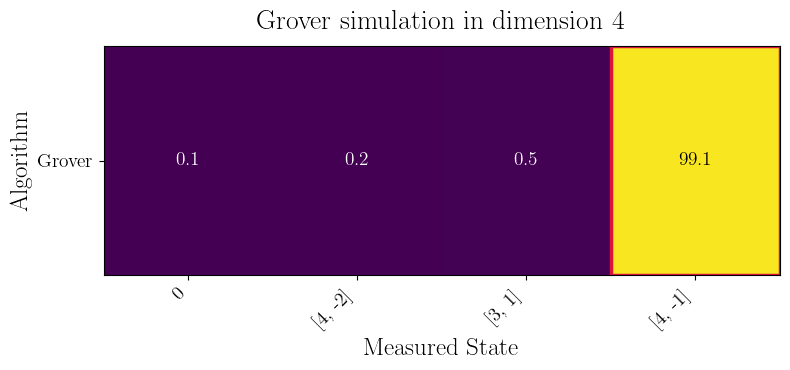

expected_output_index = 3
pulse_train_list = [[0, 4, -1], [0, 3, 1], [0, 4, -2], [0, 4, -2], [0, 3, 1], [0, 4, -1], [0, 3, 1], [0, 4, -2]]
pulse_angle_list = [1.0471975511965979, 1.2309594173407745, 1.5707963267948968, 1.570796326794897, 1.2309594173407747, 2.0943951023931953, 1.2309594173407747, 1.5707963267948966]
pulse_phases_list = [4.71238898038469, 4.71238898038469, 4.71238898038469, 1.5707963267948966, 1.5707963267948966, 4.71238898038469, 1.5707963267948966, 1.5707963267948966]
final_frame = [ 0.     -3.1416 -3.1416  0.    ]


In [17]:
def format_state_label(index):
    if index in mappings:
        return str(mappings[index])
    return str(index)


state_labels = [format_state_label(index) for index in range(dimension)]
mean_populations = simulation_result['mean_populations']
std_populations = simulation_result['std_populations']
population_percent = 100.0 * mean_populations[np.newaxis, :]

fig, ax = plt.subplots(figsize=(max(8, 0.9 * dimension), 3.8))
ax.imshow(
    population_percent,
    origin='lower',
    aspect='auto',
    vmin=0.0,
    vmax=100.0,
    cmap='viridis',
)

ax.set_xticks(np.arange(dimension))
ax.set_xticklabels(state_labels, rotation=45, ha='right', fontsize=14)
ax.set_yticks([0])
ax.set_yticklabels([algorithm_name], fontsize=14)
ax.set_xlabel('Measured State', fontsize=18)
ax.set_ylabel('Algorithm', fontsize=18)
ax.set_title(f'{algorithm_name} simulation in dimension {dimension}', fontsize=20, pad=12)
ax.tick_params(axis='both', which='major', labelsize=14)

for col_index in range(dimension):
    value_percent = population_percent[0, col_index]
    if value_percent < 0.05:
        continue
    text_color = 'black' if value_percent >= 60.0 else 'white'
    ax.text(
        col_index,
        0,
        f'{value_percent:.1f}',
        ha='center',
        va='center',
        color=text_color,
        fontsize=14,
        fontweight='bold',
    )

ax.add_patch(
    plt.Rectangle(
        (expected_output_index - 0.5, -0.5),
        1.0,
        1.0,
        fill=False,
        edgecolor='crimson',
        linewidth=2.5,
    )
)

plt.tight_layout()
plt.show()

print('expected_output_index =', expected_output_index)
print('pulse_train_list =', pulse_train_list)
print('pulse_angle_list =', pulse_angle_list)
print('pulse_phases_list =', pulse_phases_list)
print('final_frame =', wrap_frame(final_frame))


## Full BVA result

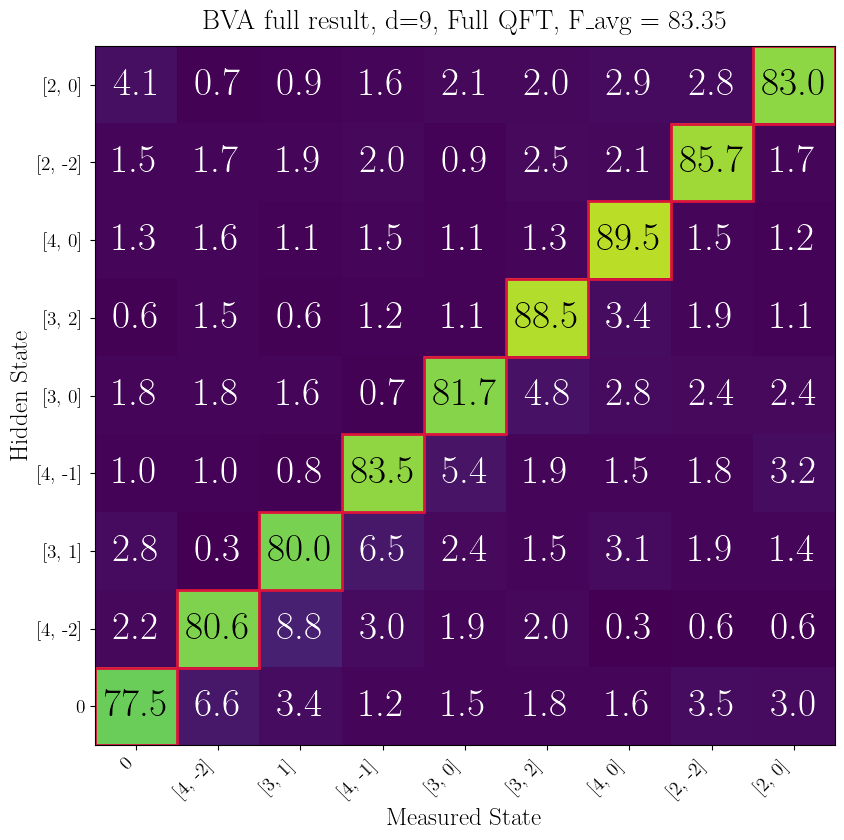

full_bva_success_probabilities = [0.7754 0.8063 0.8002 0.8352 0.8172 0.8853 0.8946 0.8569 0.8301]
avg_full_bva_success = 0.8334679212045094
std_full_bva_success = 0.03947310756971735


In [20]:
algorithm_name = "BVA"
dimension = 9
use_short_U1 = False
if str(algorithm_name).strip().lower() not in {"bva", "bv", "bernstein-vazirani", "bernstein_vazirani"}:
    raise ValueError("The full hidden-vs-measured result plot is currently implemented for BVA only.")

state_labels_full = [format_state_label(index) for index in range(dimension)]
full_bva_matrix = np.zeros((dimension, dimension), dtype=float)
full_bva_std_matrix = np.zeros((dimension, dimension), dtype=float)
full_bva_success_probabilities = []
use_line_noise = False
for hidden_value in range(dimension):
    pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
        mappings,
        dimension,
        algorithm_name,
        center=center,
        tol=tol,
        minimize_gamma=minimize_gamma,
        initial_frame=initial_frame,
        return_metadata=True,
        use_short_U1=use_short_U1,
        hidden_value=hidden_value,
    )

    final_frame_dim = compile_metadata_dim['final_frame']
    couplings_dim = compile_metadata_dim['couplings']
    thetas_dim = pulse_angle_list_dim
    phases_dim = pulse_phases_list_dim
    unitaries_dim = compile_metadata_dim['unitaries']

    initial_state_dim = basis_state(initial_state_index, dimension)
    target_state_dim = sequence_target_unitary(unitaries_dim) @ initial_state_dim

    pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)
    pulse_sensitivities_dim = np.asarray(get_values_from_matrix(pulse_train_list_dim, sens_matrix), dtype=float)

    rng_seed_dim = None if rng_seed is None else int(rng_seed) + 1000 * hidden_value
    simulation_result_dim = monte_carlo_schedule(
        couplings=couplings_dim,
        thetas=thetas_dim,
        programmed_phases=phases_dim,
        initial_state=initial_state_dim,
        pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
        default_pi_time_us=default_pi_time_us,
        pi_time_by_coupling_us=pi_time_by_coupling_us,
        per_pulse_pi_time_us=pulse_pi_times_dim,
        final_frame=wrap_frame(final_frame_dim),
        apply_final_frame=apply_final_frame,
        use_line_noise=use_line_noise,
        line_model=line_model,
        line_reference=line_reference,
        num_shots=num_shots,
        rng_seed=rng_seed_dim,
        calibration_scale=calibration_scale,
        magnetic_scale=magnetic_scale,
        laser_scale=laser_scale,
        calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
        calibration_noise_sigma_hz=calibration_noise_sigma_hz,
        magnetic_field_std_g=magnetic_field_std_g,
        laser_gaussian_T_s=laser_gaussian_T_s,
        laser_lorentzian_L_s=laser_lorentzian_L_s,
        voigt_x_min_hz=voigt_x_min_hz,
        voigt_x_max_hz=voigt_x_max_hz,
        voigt_num_points=voigt_num_points,
        rabi_frequency_std_fraction=rabi_frequency_std_fraction,
        line_signal_noise_std_g=line_signal_noise_std_g,
        target_state=target_state_dim,
    )

    full_bva_matrix[hidden_value, :] = simulation_result_dim['mean_populations']
    full_bva_std_matrix[hidden_value, :] = simulation_result_dim['std_populations']
    full_bva_success_probabilities.append(simulation_result_dim['mean_populations'][hidden_value])

full_bva_success_probabilities = np.asarray(full_bva_success_probabilities, dtype=float)
avg_full_bva_success = np.mean(full_bva_success_probabilities)
std_full_bva_success = np.std(full_bva_success_probabilities, ddof=1) if dimension > 1 else 0.0
population_percent_full = 100.0 * full_bva_matrix

fig_width = max(8.5, 0.95 * dimension)
fig_height = max(8.5, 0.8 * dimension)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.imshow(
    population_percent_full,
    origin='lower',
    aspect='auto',
    vmin=0.0,
    vmax=100.0,
    cmap='viridis',
)

ax.set_xticks(np.arange(dimension))
ax.set_xticklabels(state_labels_full, rotation=45, ha='right', fontsize=14)
ax.set_yticks(np.arange(dimension))
ax.set_yticklabels(state_labels_full, fontsize=14)
ax.set_xlabel('Measured State', fontsize=18)
ax.set_ylabel('Hidden State', fontsize=18)
ax.set_title(
    f'{algorithm_name} full result, d={dimension}, {"Short U1" if use_short_U1 else "Full QFT"}, '
    f'F_avg = {100.0 * avg_full_bva_success:.2f}%',
    fontsize=20,
    pad=12,
)
ax.tick_params(axis='both', which='major', labelsize=14)

for row_index in range(dimension):
    for col_index in range(dimension):
        value_percent = population_percent_full[row_index, col_index]
        if value_percent < 0.05:
            continue
        text_color = 'black' if value_percent >= 60.0 else 'white'
        ax.text(
            col_index,
            row_index,
            f'{value_percent:.1f}',
            ha='center',
            va='center',
            color=text_color,
            fontsize=256/dimension,
            fontweight='bold',
        )

for diag_index in range(dimension):
    ax.add_patch(
        plt.Rectangle(
            (diag_index - 0.5, diag_index - 0.5),
            1.0,
            1.0,
            fill=False,
            edgecolor='crimson',
            linewidth=2.0,
        )
    )

plt.tight_layout()
plt.show()

print('full_bva_success_probabilities =', full_bva_success_probabilities)
print('avg_full_bva_success =', avg_full_bva_success)
print('std_full_bva_success =', std_full_bva_success)


## Average Fidelity VS Dimension

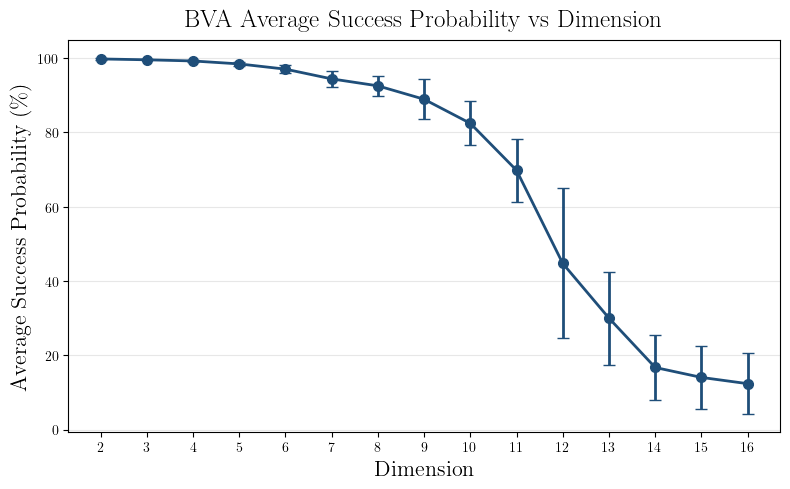

dimensions_to_sweep = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
avg_success_probability_by_dimension = [0.998  0.9957 0.9926 0.9847 0.9706 0.9444 0.9256 0.8895 0.8247 0.6982
 0.4475 0.3002 0.1674 0.1406 0.1237]
std_success_probability_by_dimension = [0.0026 0.001  0.0024 0.0053 0.0099 0.0213 0.0278 0.0542 0.0593 0.0844
 0.2018 0.1251 0.0878 0.0844 0.0815]
d= 2: avg success =  99.80% , std across hidden values =   0.26%
d= 3: avg success =  99.57% , std across hidden values =   0.10%
d= 4: avg success =  99.26% , std across hidden values =   0.24%
d= 5: avg success =  98.47% , std across hidden values =   0.53%
d= 6: avg success =  97.06% , std across hidden values =   0.99%
d= 7: avg success =  94.44% , std across hidden values =   2.13%
d= 8: avg success =  92.56% , std across hidden values =   2.78%
d= 9: avg success =  88.95% , std across hidden values =   5.42%
d=10: avg success =  82.47% , std across hidden values =   5.93%
d=11: avg success =  69.82% , std across hidde

In [30]:
if str(algorithm_name).strip().lower() not in {"bva", "bv", "bernstein-vazirani", "bernstein_vazirani"}:
    raise ValueError("This dimension-scaling sweep is currently implemented for BVA only.")

max_supported_dimension = max(mappings.keys()) + 1
dimensions_to_sweep = list(range(2, max_supported_dimension + 1))
avg_success_probability_by_dimension = []
std_success_probability_by_dimension = []
success_probabilities_by_dimension = {}

for dim_test in dimensions_to_sweep:
    dim_success_probabilities = []

    for hidden_value in range(dim_test):
        pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
            mappings,
            dim_test,
            algorithm_name,
            center=center,
            tol=tol,
            minimize_gamma=minimize_gamma,
            initial_frame=initial_frame,
            return_metadata=True,
            use_short_U1=use_short_U1,
            hidden_value=hidden_value,
        )

        final_frame_dim = compile_metadata_dim['final_frame']
        couplings_dim = compile_metadata_dim['couplings']
        thetas_dim = pulse_angle_list_dim
        phases_dim = pulse_phases_list_dim
        unitaries_dim = compile_metadata_dim['unitaries']

        initial_state_dim = basis_state(initial_state_index, dim_test)
        target_state_dim = sequence_target_unitary(unitaries_dim) @ initial_state_dim
        expected_output_index_dim = hidden_value

        pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)
        pulse_sensitivities_dim = np.asarray(get_values_from_matrix(pulse_train_list_dim, sens_matrix), dtype=float)

        simulation_result_dim = monte_carlo_schedule(
            couplings=couplings_dim,
            thetas=thetas_dim,
            programmed_phases=phases_dim,
            initial_state=initial_state_dim,
            pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
            default_pi_time_us=default_pi_time_us,
            pi_time_by_coupling_us=pi_time_by_coupling_us,
            per_pulse_pi_time_us=pulse_pi_times_dim,
            final_frame=wrap_frame(final_frame_dim),
            apply_final_frame=apply_final_frame,
            use_line_noise=use_line_noise,
            line_model=line_model,
            line_reference=line_reference,
            num_shots=num_shots,
            rng_seed=None if rng_seed is None else int(rng_seed) + 1000 * dim_test + hidden_value,
            calibration_scale=calibration_scale,
            magnetic_scale=magnetic_scale,
            laser_scale=laser_scale,
            calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
            calibration_noise_sigma_hz=calibration_noise_sigma_hz,
            magnetic_field_std_g=magnetic_field_std_g,
            laser_gaussian_T_s=laser_gaussian_T_s,
            laser_lorentzian_L_s=laser_lorentzian_L_s,
            voigt_x_min_hz=voigt_x_min_hz,
            voigt_x_max_hz=voigt_x_max_hz,
            voigt_num_points=voigt_num_points,
            rabi_frequency_std_fraction=rabi_frequency_std_fraction,
            line_signal_noise_std_g=line_signal_noise_std_g,
            target_state=target_state_dim,
        )

        dim_success_probabilities.append(simulation_result_dim['mean_populations'][expected_output_index_dim])

    dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
    success_probabilities_by_dimension[dim_test] = dim_success_probabilities
    avg_success_probability_by_dimension.append(np.mean(dim_success_probabilities))
    std_success_probability_by_dimension.append(
        np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0
    )

avg_success_probability_by_dimension = np.asarray(avg_success_probability_by_dimension, dtype=float)
std_success_probability_by_dimension = np.asarray(std_success_probability_by_dimension, dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    dimensions_to_sweep,
    100.0 * avg_success_probability_by_dimension,
    yerr=100.0 * std_success_probability_by_dimension,
    fmt='o-',
    color='#1f4e79',
    ecolor='#1f4e79',
    capsize=4,
    linewidth=2,
    markersize=7,
)
ax.set_xlabel('Dimension', fontsize=16)
ax.set_ylabel('Average Success Probability (\\%)', fontsize=16)
ax.set_title(f'{algorithm_name} Average Success Probability vs Dimension', fontsize=18, pad=10)
ax.set_xticks(dimensions_to_sweep)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('dimensions_to_sweep =', dimensions_to_sweep)
print('avg_success_probability_by_dimension =', avg_success_probability_by_dimension)
print('std_success_probability_by_dimension =', std_success_probability_by_dimension)
for dim_test, mean_success, std_success in zip(
    dimensions_to_sweep,
    avg_success_probability_by_dimension,
    std_success_probability_by_dimension,
):
    print(
        f'd={dim_test:2d}: avg success = {100.0 * mean_success:6.2f}% , '
        f'std across hidden values = {100.0 * std_success:6.2f}%'
    )


## Short VS Long U1

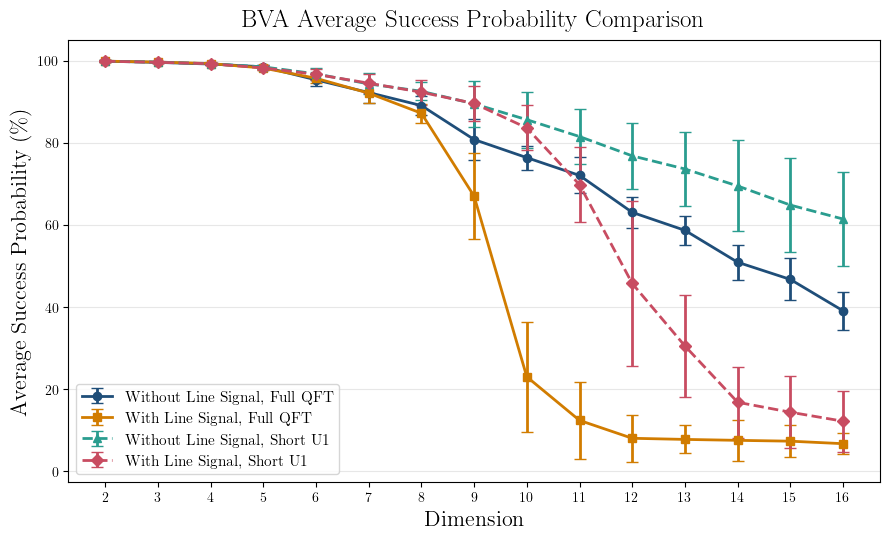


Without Line Signal, Full QFT
d= 2: avg success =  99.84% , std across hidden values =   0.21%
d= 3: avg success =  99.54% , std across hidden values =   0.09%
d= 4: avg success =  99.14% , std across hidden values =   0.25%
d= 5: avg success =  98.47% , std across hidden values =   0.51%
d= 6: avg success =  95.29% , std across hidden values =   1.43%
d= 7: avg success =  92.20% , std across hidden values =   2.46%
d= 8: avg success =  89.02% , std across hidden values =   2.25%
d= 9: avg success =  80.75% , std across hidden values =   4.97%
d=10: avg success =  76.33% , std across hidden values =   2.89%
d=11: avg success =  72.00% , std across hidden values =   4.38%
d=12: avg success =  62.99% , std across hidden values =   3.86%
d=13: avg success =  58.61% , std across hidden values =   3.46%
d=14: avg success =  50.84% , std across hidden values =   4.26%
d=15: avg success =  46.65% , std across hidden values =   5.11%
d=16: avg success =  39.00% , std across hidden values =   

In [63]:
if str(algorithm_name).strip().lower() not in {"bva", "bv", "bernstein-vazirani", "bernstein_vazirani"}:
    raise ValueError("This comparison sweep is currently implemented for BVA only.")

max_supported_dimension = max(mappings.keys()) + 1
dimensions_to_sweep = list(range(2, max_supported_dimension + 1))
comparison_configs = [
    {
        "label": "Without Line Signal, Full QFT",
        "use_line_noise": False,
        "use_short_U1": False,
        "color": "#1f4e79",
        "linestyle": "-",
        "marker": "o",
    },
    {
        "label": "With Line Signal, Full QFT",
        "use_line_noise": True,
        "use_short_U1": False,
        "color": "#d17c00",
        "linestyle": "-",
        "marker": "s",
    },
    {
        "label": "Without Line Signal, Short U1",
        "use_line_noise": False,
        "use_short_U1": True,
        "color": "#2a9d8f",
        "linestyle": "--",
        "marker": "^",
    },
    {
        "label": "With Line Signal, Short U1",
        "use_line_noise": True,
        "use_short_U1": True,
        "color": "#c84c61",
        "linestyle": "--",
        "marker": "D",
    },
]

comparison_results = {}

for config in comparison_configs:
    avg_success_probability = []
    std_success_probability = []
    success_by_dimension = {}

    for dim_test in dimensions_to_sweep:
        dim_success_probabilities = []

        for hidden_value in range(dim_test):
            pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
                mappings,
                dim_test,
                algorithm_name,
                center=center,
                tol=tol,
                minimize_gamma=minimize_gamma,
                initial_frame=initial_frame,
                return_metadata=True,
                use_short_U1=config["use_short_U1"],
                hidden_value=hidden_value,
            )

            final_frame_dim = compile_metadata_dim["final_frame"]
            couplings_dim = compile_metadata_dim["couplings"]
            thetas_dim = pulse_angle_list_dim
            phases_dim = pulse_phases_list_dim
            unitaries_dim = compile_metadata_dim["unitaries"]

            initial_state_dim = basis_state(initial_state_index, dim_test)
            target_state_dim = sequence_target_unitary(unitaries_dim) @ initial_state_dim
            expected_output_index_dim = hidden_value

            pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)
            pulse_sensitivities_dim = np.asarray(get_values_from_matrix(pulse_train_list_dim, sens_matrix), dtype=float)

            simulation_result_dim = monte_carlo_schedule(
                couplings=couplings_dim,
                thetas=thetas_dim,
                programmed_phases=phases_dim,
                initial_state=initial_state_dim,
                pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
                default_pi_time_us=default_pi_time_us,
                pi_time_by_coupling_us=pi_time_by_coupling_us,
                per_pulse_pi_time_us=pulse_pi_times_dim,
                final_frame=wrap_frame(final_frame_dim),
                apply_final_frame=apply_final_frame,
                use_line_noise=config["use_line_noise"],
                line_model=line_model,
                line_reference=line_reference,
                num_shots=num_shots,
                rng_seed=None if rng_seed is None else int(rng_seed) + 100000 * int(config["use_short_U1"]) + 10000 * int(config["use_line_noise"]) + 1000 * dim_test + hidden_value,
                calibration_scale=calibration_scale,
                magnetic_scale=magnetic_scale,
                laser_scale=laser_scale,
                calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
                calibration_noise_sigma_hz=calibration_noise_sigma_hz,
                magnetic_field_std_g=magnetic_field_std_g,
                laser_gaussian_T_s=laser_gaussian_T_s,
                laser_lorentzian_L_s=laser_lorentzian_L_s,
                voigt_x_min_hz=voigt_x_min_hz,
                voigt_x_max_hz=voigt_x_max_hz,
                voigt_num_points=voigt_num_points,
                rabi_frequency_std_fraction=rabi_frequency_std_fraction,
                line_signal_noise_std_g=line_signal_noise_std_g,
                target_state=target_state_dim,
            )

            dim_success_probabilities.append(simulation_result_dim["mean_populations"][expected_output_index_dim])

        dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
        success_by_dimension[dim_test] = dim_success_probabilities
        avg_success_probability.append(np.mean(dim_success_probabilities))
        std_success_probability.append(
            np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0
        )

    comparison_results[config["label"]] = {
        "use_line_noise": config["use_line_noise"],
        "use_short_U1": config["use_short_U1"],
        "dimensions": np.asarray(dimensions_to_sweep, dtype=int),
        "avg_success_probability": np.asarray(avg_success_probability, dtype=float),
        "std_success_probability": np.asarray(std_success_probability, dtype=float),
        "success_by_dimension": success_by_dimension,
    }

fig, ax = plt.subplots(figsize=(9, 5.5))
for config in comparison_configs:
    result = comparison_results[config["label"]]
    ax.errorbar(
        result["dimensions"],
        100.0 * result["avg_success_probability"],
        yerr=100.0 * result["std_success_probability"],
        fmt=config["marker"],
        linestyle=config["linestyle"],
        color=config["color"],
        ecolor=config["color"],
        capsize=4,
        linewidth=2,
        markersize=6,
        label=config["label"],
    )

ax.set_xlabel("Dimension", fontsize=16)
ax.set_ylabel(r"Average Success Probability (\%)", fontsize=16)
ax.set_title(f"{algorithm_name} Average Success Probability Comparison", fontsize=18, pad=10)
ax.set_xticks(dimensions_to_sweep)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

for config in comparison_configs:
    result = comparison_results[config["label"]]
    print("\n" + config["label"])
    for dim_test, mean_success, std_success in zip(
        result["dimensions"],
        result["avg_success_probability"],
        result["std_success_probability"],
    ):
        print(
            f"d={dim_test:2d}: avg success = {100.0 * mean_success:6.2f}% , std across hidden values = {100.0 * std_success:6.2f}%"
        )


In [32]:
from pathlib import Path

if 'comparison_results' not in globals():
    raise ValueError('Run the comparison sweep cell before saving results.')

algorithm_name_slug = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(algorithm_name)).strip('_') or 'algorithm'
comparison_save_base = Path(
    rf"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\{algorithm_name_slug}_dimension_comparison"
)
comparison_npz_path = comparison_save_base.with_suffix('.npz')
comparison_txt_path = comparison_save_base.with_suffix('.txt')

curve_names = list(comparison_results.keys())
dimensions_saved = np.asarray(dimensions_to_sweep, dtype=int)
max_hidden_count = max(int(dim) for dim in dimensions_saved)

avg_success_matrix = np.full((len(curve_names), len(dimensions_saved)), np.nan, dtype=float)
std_success_matrix = np.full((len(curve_names), len(dimensions_saved)), np.nan, dtype=float)
success_cube = np.full((len(curve_names), len(dimensions_saved), max_hidden_count), np.nan, dtype=float)
use_line_noise_by_curve = np.zeros(len(curve_names), dtype=bool)
use_short_u1_by_curve = np.zeros(len(curve_names), dtype=bool)

for curve_index, curve_name in enumerate(curve_names):
    result = comparison_results[curve_name]
    avg_success_matrix[curve_index, :] = np.asarray(result['avg_success_probability'], dtype=float)
    std_success_matrix[curve_index, :] = np.asarray(result['std_success_probability'], dtype=float)
    use_line_noise_by_curve[curve_index] = bool(result['use_line_noise'])
    use_short_u1_by_curve[curve_index] = bool(result['use_short_U1'])

    for dim_index, dim_value in enumerate(dimensions_saved):
        dim_success = np.asarray(result['success_by_dimension'][int(dim_value)], dtype=float)
        success_cube[curve_index, dim_index, :len(dim_success)] = dim_success

np.savez_compressed(
    comparison_npz_path,
    algorithm_name=np.asarray([str(algorithm_name)]),
    curve_names=np.asarray(curve_names, dtype='<U64'),
    dimensions=dimensions_saved,
    avg_success_matrix=avg_success_matrix,
    std_success_matrix=std_success_matrix,
    success_cube=success_cube,
    use_line_noise_by_curve=use_line_noise_by_curve.astype(int),
    use_short_u1_by_curve=use_short_u1_by_curve.astype(int),
)

with comparison_txt_path.open('w', encoding='utf-8') as f:
    f.write(f'Algorithm: {algorithm_name}\n')
    f.write('Saved dimension comparison results\n\n')
    for curve_index, curve_name in enumerate(curve_names):
        f.write(f'{curve_name}\n')
        f.write(f'  use_line_noise = {bool(use_line_noise_by_curve[curve_index])}\n')
        f.write(f'  use_short_U1  = {bool(use_short_u1_by_curve[curve_index])}\n')
        for dim_value, mean_success, std_success in zip(
            dimensions_saved,
            avg_success_matrix[curve_index],
            std_success_matrix[curve_index],
        ):
            f.write(
                f'  d={int(dim_value):2d}: avg success = {100.0 * mean_success:6.2f}% , '
                f'std across hidden values = {100.0 * std_success:6.2f}%\n'
            )
        f.write('\n')

print(f'Saved NPZ results to: {comparison_npz_path}')
print(f'Saved text summary to: {comparison_txt_path}')


Saved NPZ results to: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\bva_dimension_comparison.npz
Saved text summary to: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\bva_dimension_comparison.txt


## Isolated Error Signal

Running Without Line Signal...
Running With Line Signal...
Running Magnetic Field Only...
Running Laser Noise Only...
Running Calibration Noise Only...
Running Rabi Frequency Only...
Running Line Signal Only...


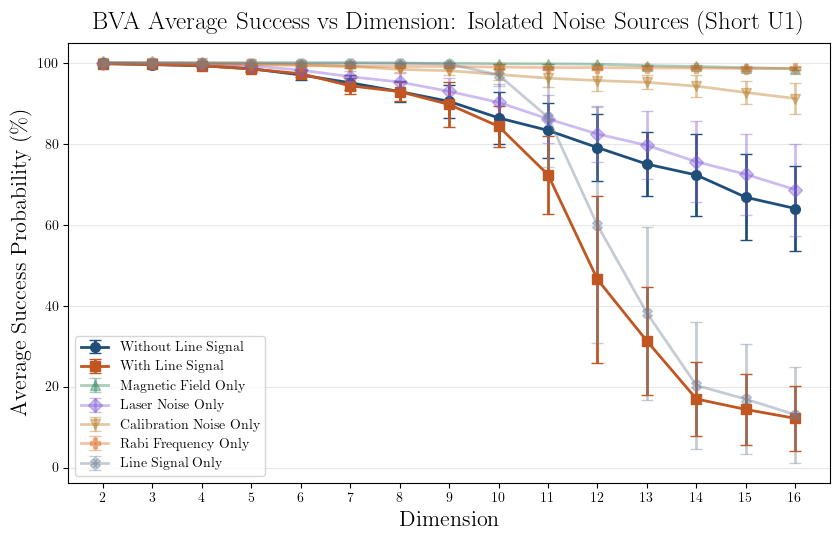

Cache file: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\bva_isolated_noise_sources_short_u1.npz
Loaded from saved run: False
Without Line Signal
  d= 2: mean success =  99.85% , std across hidden values =   0.20%
  d= 3: mean success =  99.58% , std across hidden values =   0.15%
  d= 4: mean success =  99.29% , std across hidden values =   0.28%
  d= 5: mean success =  98.56% , std across hidden values =   0.54%
  d= 6: mean success =  97.02% , std across hidden values =   1.15%
  d= 7: mean success =  95.09% , std across hidden values =   1.86%
  d= 8: mean success =  92.91% , std across hidden values =   2.61%
  d= 9: mean success =  90.49% , std across hidden values =   4.13%
  d=10: mean success =  86.41% , std across hidden values =   6.38%
  d=11: mean success =  83.31% , std across hidden values =   6.75%
  d=12: mean success =  79.07% , std across hidden values =   8.27%
  d=13: mean success =  74.98% , std across hidden values =   7.95%
  

In [65]:
from pathlib import Path

if str(algorithm_name).strip().lower() not in {"bva", "bv", "bernstein-vazirani", "bernstein_vazirani"}:
    raise ValueError("This isolated-noise sweep is currently implemented for BVA only.")
use_short_U1 = True
prep_mode_label = 'short_u1' if use_short_U1 else 'full_qft'
algorithm_name_slug = ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(algorithm_name)).strip('_') or 'algorithm'
isolated_noise_cache_path = Path(
    rf"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\BVA_analysis_scripts\{algorithm_name_slug}_isolated_noise_sources_{prep_mode_label}.npz"
)
rerun_isolated_noise_sources = True

max_supported_dimension = max(mappings.keys()) + 1
dimensions_to_test = list(range(2, max_supported_dimension + 1))
max_hidden_count = max(dimensions_to_test)

curve_specs = {
    'Without Line Signal': {
        'use_line_noise': False,
        'calibration_scale': calibration_scale,
        'magnetic_scale': magnetic_scale,
        'laser_scale': laser_scale,
        'rabi_frequency_std_fraction': rabi_frequency_std_fraction,
        'line_signal_noise_std_g': line_signal_noise_std_g,
        'color': '#1f4e79',
        'marker': 'o',
        'alpha': 1.0,
    },
    'With Line Signal': {
        'use_line_noise': True,
        'calibration_scale': calibration_scale,
        'magnetic_scale': magnetic_scale,
        'laser_scale': laser_scale,
        'rabi_frequency_std_fraction': rabi_frequency_std_fraction,
        'line_signal_noise_std_g': line_signal_noise_std_g,
        'color': '#c05621',
        'marker': 's',
        'alpha': 1.0,
    },
    'Magnetic Field Only': {
        'use_line_noise': False,
        'calibration_scale': 0.0,
        'magnetic_scale': magnetic_scale,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': 0.0,
        'color': '#2f855a',
        'marker': '^',
        'alpha': 0.4,
    },
    'Laser Noise Only': {
        'use_line_noise': False,
        'calibration_scale': 0.0,
        'magnetic_scale': 0.0,
        'laser_scale': laser_scale,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': 0.0,
        'color': '#805ad5',
        'marker': 'D',
        'alpha': 0.4,
    },
    'Calibration Noise Only': {
        'use_line_noise': False,
        'calibration_scale': calibration_scale,
        'magnetic_scale': 0.0,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': 0.0,
        'color': '#b7791f',
        'marker': 'v',
        'alpha': 0.4,
    },
    'Rabi Frequency Only': {
        'use_line_noise': False,
        'calibration_scale': 0.0,
        'magnetic_scale': 0.0,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': rabi_frequency_std_fraction,
        'line_signal_noise_std_g': 0.0,
        'color': '#dd6b20',
        'marker': 'P',
        'alpha': 0.4,
    },
    'Line Signal Only': {
        'use_line_noise': True,
        'calibration_scale': 0.0,
        'magnetic_scale': 0.0,
        'laser_scale': 0.0,
        'rabi_frequency_std_fraction': 0.0,
        'line_signal_noise_std_g': line_signal_noise_std_g,
        'color': '#718096',
        'marker': 'X',
        'alpha': 0.4,
    },
}
curve_order = list(curve_specs.keys())


def curve_cache_key(label):
    return label.lower().replace(' ', '_')


def run_dimension_success_curve(curve_cfg, curve_seed_offset):
    mean_success_by_dimension = []
    std_success_by_dimension = []
    all_success_padded = []

    for dim_test in dimensions_to_test:
        dim_success_probabilities = []

        for hidden_value in range(dim_test):
            pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
                mappings,
                dim_test,
                algorithm_name,
                center=center,
                tol=tol,
                minimize_gamma=minimize_gamma,
                initial_frame=initial_frame,
                return_metadata=True,
                use_short_U1=use_short_U1,
                hidden_value=hidden_value,
            )

            final_frame_dim = compile_metadata_dim['final_frame']
            couplings_dim = compile_metadata_dim['couplings']
            thetas_dim = pulse_angle_list_dim
            phases_dim = pulse_phases_list_dim
            unitaries_dim = compile_metadata_dim['unitaries']

            initial_state_dim = basis_state(initial_state_index, dim_test)
            target_state_dim = sequence_target_unitary(unitaries_dim) @ initial_state_dim
            expected_output_index_dim = hidden_value

            pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)
            pulse_sensitivities_dim = np.asarray(get_values_from_matrix(pulse_train_list_dim, sens_matrix), dtype=float)

            simulation_result_dim = monte_carlo_schedule(
                couplings=couplings_dim,
                thetas=thetas_dim,
                programmed_phases=phases_dim,
                initial_state=initial_state_dim,
                pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
                default_pi_time_us=default_pi_time_us,
                pi_time_by_coupling_us=pi_time_by_coupling_us,
                per_pulse_pi_time_us=pulse_pi_times_dim,
                final_frame=wrap_frame(final_frame_dim),
                apply_final_frame=apply_final_frame,
                use_line_noise=curve_cfg['use_line_noise'],
                line_model=line_model,
                line_reference=line_reference,
                num_shots=num_shots,
                rng_seed=None if rng_seed is None else int(rng_seed) + 100000 * curve_seed_offset + 1000 * dim_test + hidden_value,
                calibration_scale=curve_cfg['calibration_scale'],
                magnetic_scale=curve_cfg['magnetic_scale'],
                laser_scale=curve_cfg['laser_scale'],
                calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
                calibration_noise_sigma_hz=calibration_noise_sigma_hz,
                magnetic_field_std_g=magnetic_field_std_g,
                laser_gaussian_T_s=laser_gaussian_T_s,
                laser_lorentzian_L_s=laser_lorentzian_L_s,
                voigt_x_min_hz=voigt_x_min_hz,
                voigt_x_max_hz=voigt_x_max_hz,
                voigt_num_points=voigt_num_points,
                rabi_frequency_std_fraction=curve_cfg['rabi_frequency_std_fraction'],
                line_signal_noise_std_g=curve_cfg['line_signal_noise_std_g'],
                target_state=target_state_dim,
            )

            dim_success_probabilities.append(simulation_result_dim['mean_populations'][expected_output_index_dim])

        dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
        padded_success = np.full(max_hidden_count, np.nan, dtype=float)
        padded_success[:len(dim_success_probabilities)] = dim_success_probabilities
        all_success_padded.append(padded_success)

        mean_success_by_dimension.append(np.mean(dim_success_probabilities))
        std_success_by_dimension.append(np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0)

    return {
        'mean_success_by_dimension': np.asarray(mean_success_by_dimension, dtype=float),
        'std_success_by_dimension': np.asarray(std_success_by_dimension, dtype=float),
        'all_success_padded': np.asarray(all_success_padded, dtype=float),
    }


if rerun_isolated_noise_sources or not isolated_noise_cache_path.exists():
    isolated_noise_results = {}
    cache_arrays = {
        'dimensions_to_test': np.asarray(dimensions_to_test, dtype=int),
        'curve_names': np.asarray(curve_order, dtype='<U64'),
        'use_short_U1': np.asarray([int(bool(use_short_U1))], dtype=int),
    }

    for curve_index, curve_name in enumerate(curve_order):
        print(f'Running {curve_name}...')
        curve_result = run_dimension_success_curve(curve_specs[curve_name], curve_index)
        isolated_noise_results[curve_name] = curve_result
        key = curve_cache_key(curve_name)
        cache_arrays[f'{key}_mean_success_by_dimension'] = curve_result['mean_success_by_dimension']
        cache_arrays[f'{key}_std_success_by_dimension'] = curve_result['std_success_by_dimension']
        cache_arrays[f'{key}_all_success_padded'] = curve_result['all_success_padded']

    np.savez_compressed(isolated_noise_cache_path, **cache_arrays)
else:
    cache_arrays = np.load(isolated_noise_cache_path)
    cached_curve_names = [str(name) for name in cache_arrays['curve_names']]
    if cached_curve_names != curve_order:
        raise ValueError('Cached isolated-noise results do not match the current curve definitions. Set rerun_isolated_noise_sources = True.')

    dimensions_to_test = cache_arrays['dimensions_to_test'].astype(int).tolist()
    isolated_noise_results = {}
    for curve_name in curve_order:
        key = curve_cache_key(curve_name)
        isolated_noise_results[curve_name] = {
            'mean_success_by_dimension': np.asarray(cache_arrays[f'{key}_mean_success_by_dimension'], dtype=float),
            'std_success_by_dimension': np.asarray(cache_arrays[f'{key}_std_success_by_dimension'], dtype=float),
            'all_success_padded': np.asarray(cache_arrays[f'{key}_all_success_padded'], dtype=float),
        }

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for curve_name in curve_order:
    style = curve_specs[curve_name]
    means = 100.0 * isolated_noise_results[curve_name]['mean_success_by_dimension']
    stds = 100.0 * isolated_noise_results[curve_name]['std_success_by_dimension']
    ax.errorbar(
        dimensions_to_test,
        means,
        yerr=stds,
        fmt=f"{style['marker']}-",
        color=style['color'],
        ecolor=style['color'],
        capsize=4,
        linewidth=2,
        markersize=7,
        alpha=style['alpha'],
        label=curve_name,
    )

prep_mode_title = 'Short U1' if use_short_U1 else 'Full QFT'
ax.set_xlabel('Dimension', fontsize=16)
ax.set_ylabel(r'Average Success Probability (\%)', fontsize=16)
ax.set_title(f'{algorithm_name} Average Success vs Dimension: Isolated Noise Sources ({prep_mode_title})', fontsize=18, pad=10)
ax.set_xticks(dimensions_to_test)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Cache file: {isolated_noise_cache_path}')
print(f'Loaded from saved run: {not rerun_isolated_noise_sources and isolated_noise_cache_path.exists()}')
for curve_name in curve_order:
    print(curve_name)
    means = isolated_noise_results[curve_name]['mean_success_by_dimension']
    stds = isolated_noise_results[curve_name]['std_success_by_dimension']
    for dim_test, mean_success, std_success in zip(dimensions_to_test, means, stds):
        print(f'  d={dim_test:2d}: mean success = {100.0 * mean_success:6.2f}% , std across hidden values = {100.0 * std_success:6.2f}%')


## Full Grover Result (1 Iteration)

Simulate one Grover iteration for every marked state in a fixed dimension and plot the marked-vs-measured confusion matrix.


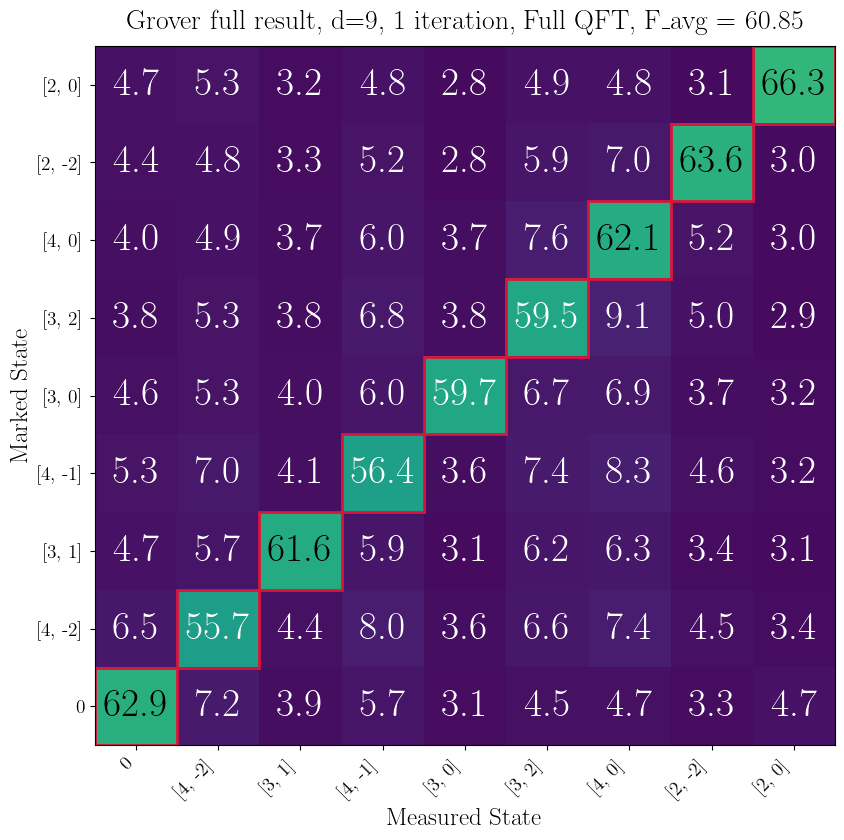

full_grover_success_probabilities = [0.629  0.5567 0.6157 0.5638 0.5967 0.5946 0.6209 0.6359 0.6634]
avg_full_grover_success = 0.6085154124125831
std_full_grover_success = 0.034264718045329434


In [23]:
grover_algorithm_name = "Grover"
grover_iterations = 1
max_supported_dimension = max(mappings.keys()) + 1
grover_dimension = min(9, max_supported_dimension)
use_short_U1_override = True
def simulate_grover_case(dim_test, marked_state, grover_iterations=1, use_short_U1_override=None, rng_seed_offset=0):
    if use_short_U1_override is None:
        use_short_U1_override = use_short_U1

    pulse_train_list_dim, pulse_angle_list_dim, pulse_phases_list_dim, compile_metadata_dim = compile_algorithm_pulses(
        mappings,
        dim_test,
        grover_algorithm_name,
        center=center,
        tol=tol,
        minimize_gamma=minimize_gamma,
        initial_frame=initial_frame,
        return_metadata=True,
        use_short_U1=use_short_U1_override,
        marked_state=marked_state,
        grover_iterations=grover_iterations,
    )

    final_frame_dim = compile_metadata_dim['final_frame']
    couplings_dim = compile_metadata_dim['couplings']
    thetas_dim = pulse_angle_list_dim
    phases_dim = pulse_phases_list_dim
    unitaries_dim = compile_metadata_dim['unitaries']

    initial_state_dim = basis_state(initial_state_index, dim_test)
    target_state_dim = sequence_target_unitary(unitaries_dim) @ initial_state_dim

    pulse_pi_times_dim = np.asarray(get_pi_times(pulse_train_list_dim), dtype=float)
    pulse_sensitivities_dim = np.asarray(get_values_from_matrix(pulse_train_list_dim, sens_matrix), dtype=float)

    rng_seed_dim = None if rng_seed is None else int(rng_seed) + int(rng_seed_offset) + 1000 * int(dim_test) + int(marked_state)
    simulation_result_dim = monte_carlo_schedule(
        couplings=couplings_dim,
        thetas=thetas_dim,
        programmed_phases=phases_dim,
        initial_state=initial_state_dim,
        pulse_sensitivities_mhz_per_g=pulse_sensitivities_dim,
        default_pi_time_us=default_pi_time_us,
        pi_time_by_coupling_us=pi_time_by_coupling_us,
        per_pulse_pi_time_us=pulse_pi_times_dim,
        final_frame=wrap_frame(final_frame_dim),
        apply_final_frame=apply_final_frame,
        use_line_noise=use_line_noise,
        line_model=line_model,
        line_reference=line_reference,
        num_shots=num_shots,
        rng_seed=rng_seed_dim,
        calibration_scale=calibration_scale,
        magnetic_scale=magnetic_scale,
        laser_scale=laser_scale,
        calibration_noise_hwhm_hz=calibration_noise_hwhm_hz,
        calibration_noise_sigma_hz=calibration_noise_sigma_hz,
        magnetic_field_std_g=magnetic_field_std_g,
        laser_gaussian_T_s=laser_gaussian_T_s,
        laser_lorentzian_L_s=laser_lorentzian_L_s,
        voigt_x_min_hz=voigt_x_min_hz,
        voigt_x_max_hz=voigt_x_max_hz,
        voigt_num_points=voigt_num_points,
        rabi_frequency_std_fraction=rabi_frequency_std_fraction,
        line_signal_noise_std_g=line_signal_noise_std_g,
        target_state=target_state_dim,
    )

    return {
        'pulse_train_list': pulse_train_list_dim,
        'pulse_angle_list': pulse_angle_list_dim,
        'pulse_phases_list': pulse_phases_list_dim,
        'compile_metadata': compile_metadata_dim,
        'simulation_result': simulation_result_dim,
        'target_state': target_state_dim,
    }

state_labels_grover = [format_state_label(index) for index in range(grover_dimension)]
full_grover_matrix = np.zeros((grover_dimension, grover_dimension), dtype=float)
full_grover_std_matrix = np.zeros((grover_dimension, grover_dimension), dtype=float)
full_grover_success_probabilities = []

for marked_state in range(grover_dimension):
    grover_case_result = simulate_grover_case(
        grover_dimension,
        marked_state,
        grover_iterations=grover_iterations,
        use_short_U1_override=use_short_U1,
    )
    simulation_result_dim = grover_case_result['simulation_result']
    full_grover_matrix[marked_state, :] = simulation_result_dim['mean_populations']
    full_grover_std_matrix[marked_state, :] = simulation_result_dim['std_populations']
    full_grover_success_probabilities.append(simulation_result_dim['mean_populations'][marked_state])

full_grover_success_probabilities = np.asarray(full_grover_success_probabilities, dtype=float)
avg_full_grover_success = np.mean(full_grover_success_probabilities)
std_full_grover_success = np.std(full_grover_success_probabilities, ddof=1) if grover_dimension > 1 else 0.0
population_percent_grover = 100.0 * full_grover_matrix

fig_width = max(8.5, 0.95 * grover_dimension)
fig_height = max(8.5, 0.8 * grover_dimension)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.imshow(
    population_percent_grover,
    origin='lower',
    aspect='auto',
    vmin=0.0,
    vmax=100.0,
    cmap='viridis',
)

ax.set_xticks(np.arange(grover_dimension))
ax.set_xticklabels(state_labels_grover, rotation=45, ha='right', fontsize=14)
ax.set_yticks(np.arange(grover_dimension))
ax.set_yticklabels(state_labels_grover, fontsize=14)
ax.set_xlabel('Measured State', fontsize=18)
ax.set_ylabel('Marked State', fontsize=18)
ax.set_title(
    f'Grover full result, d={grover_dimension}, 1 iteration, ' +
    f'{"Short U1" if use_short_U1 else "Full QFT"}, ' +
    f'F_avg = {100.0 * avg_full_grover_success:.2f}%',
    fontsize=20,
    pad=12,
)
ax.tick_params(axis='both', which='major', labelsize=14)

for row_index in range(grover_dimension):
    for col_index in range(grover_dimension):
        value_percent = population_percent_grover[row_index, col_index]
        if value_percent < 0.05:
            continue
        text_color = 'black' if value_percent >= 60.0 else 'white'
        ax.text(
            col_index,
            row_index,
            f'{value_percent:.1f}',
            ha='center',
            va='center',
            color=text_color,
            fontsize=256 / grover_dimension,
            fontweight='bold',
        )

for diag_index in range(grover_dimension):
    ax.add_patch(
        plt.Rectangle(
            (diag_index - 0.5, diag_index - 0.5),
            1.0,
            1.0,
            fill=False,
            edgecolor='crimson',
            linewidth=2.0,
        )
    )

plt.tight_layout()
plt.show()

print('full_grover_success_probabilities =', full_grover_success_probabilities)
print('avg_full_grover_success =', avg_full_grover_success)
print('std_full_grover_success =', std_full_grover_success)


## Grover Average Success VS Dimension (1 Iteration)

Sweep qudit dimension and average the Grover one-iteration success probability over every marked state.


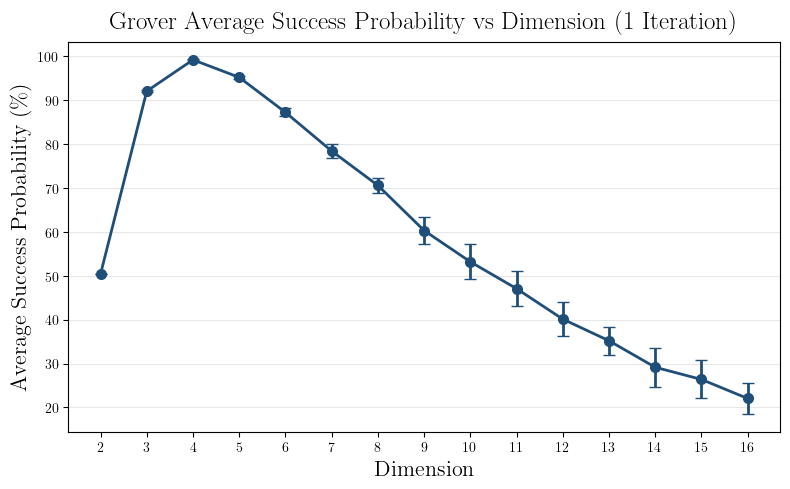

grover_dimensions_to_sweep = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
grover_avg_success_probability_by_dimension = [0.5038 0.9205 0.9919 0.952  0.8722 0.7841 0.7057 0.603  0.5318 0.4706
 0.4012 0.3519 0.2915 0.2638 0.2204]
grover_std_success_probability_by_dimension = [0.0008 0.0023 0.0012 0.0037 0.0088 0.016  0.0166 0.0301 0.04   0.0406
 0.0382 0.0321 0.0442 0.0432 0.0354]
d= 2: avg success =  50.38% , std across marked states =   0.08%
d= 3: avg success =  92.05% , std across marked states =   0.23%
d= 4: avg success =  99.19% , std across marked states =   0.12%
d= 5: avg success =  95.20% , std across marked states =   0.37%
d= 6: avg success =  87.22% , std across marked states =   0.88%
d= 7: avg success =  78.41% , std across marked states =   1.60%
d= 8: avg success =  70.57% , std across marked states =   1.66%
d= 9: avg success =  60.30% , std across marked states =   3.01%
d=10: avg success =  53.18% , std across marked states =   4.00%
d=11: avg success =  47.0

In [22]:
if 'simulate_grover_case' not in globals():
    raise ValueError('Run the full Grover result cell first.')

grover_dimension_sweep_iterations = 1
max_supported_dimension = max(mappings.keys()) + 1
grover_dimensions_to_sweep = list(range(2, max_supported_dimension + 1))
grover_avg_success_probability_by_dimension = []
grover_std_success_probability_by_dimension = []
grover_success_probabilities_by_dimension = {}

for dim_test in grover_dimensions_to_sweep:
    dim_success_probabilities = []

    for marked_state in range(dim_test):
        grover_case_result = simulate_grover_case(
            dim_test,
            marked_state,
            grover_iterations=grover_dimension_sweep_iterations,
            use_short_U1_override=use_short_U1,
            rng_seed_offset=100000,
        )
        simulation_result_dim = grover_case_result['simulation_result']
        dim_success_probabilities.append(simulation_result_dim['mean_populations'][marked_state])

    dim_success_probabilities = np.asarray(dim_success_probabilities, dtype=float)
    grover_success_probabilities_by_dimension[dim_test] = dim_success_probabilities
    grover_avg_success_probability_by_dimension.append(np.mean(dim_success_probabilities))
    grover_std_success_probability_by_dimension.append(
        np.std(dim_success_probabilities, ddof=1) if len(dim_success_probabilities) > 1 else 0.0
    )

grover_avg_success_probability_by_dimension = np.asarray(grover_avg_success_probability_by_dimension, dtype=float)
grover_std_success_probability_by_dimension = np.asarray(grover_std_success_probability_by_dimension, dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    grover_dimensions_to_sweep,
    100.0 * grover_avg_success_probability_by_dimension,
    yerr=100.0 * grover_std_success_probability_by_dimension,
    fmt='o-',
    color='#1f4e79',
    ecolor='#1f4e79',
    capsize=4,
    linewidth=2,
    markersize=7,
)
ax.set_xlabel('Dimension', fontsize=16)
ax.set_ylabel('Average Success Probability (\\%)', fontsize=16)
ax.set_title('Grover Average Success Probability vs Dimension (1 Iteration)', fontsize=18, pad=10)
ax.set_xticks(grover_dimensions_to_sweep)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('grover_dimensions_to_sweep =', grover_dimensions_to_sweep)
print('grover_avg_success_probability_by_dimension =', grover_avg_success_probability_by_dimension)
print('grover_std_success_probability_by_dimension =', grover_std_success_probability_by_dimension)
for dim_test, mean_success, std_success in zip(
    grover_dimensions_to_sweep,
    grover_avg_success_probability_by_dimension,
    grover_std_success_probability_by_dimension,
):
    print(
        f'd={dim_test:2d}: avg success = {100.0 * mean_success:6.2f}% , ' +
        f'std across marked states = {100.0 * std_success:6.2f}%'
    )


NameError: name 'batch_results' is not defined